In [2]:
import pandas as pd

csv_roof = '../files2/final'
df_acc = pd.read_csv(f"{csv_roof}/seoul_accidents.csv")
df_light = pd.read_csv(f"{csv_roof}/seoul_traffic_lights.csv")
df_acc = df_acc[df_acc['district'] == '강남구']
df_light = df_light[df_light['district'] == '강남구']

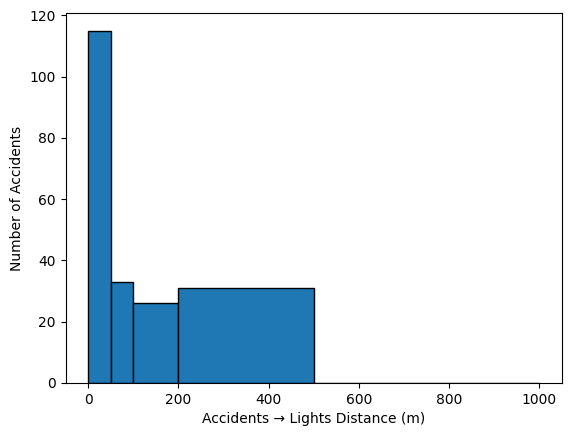

In [4]:
# KD-Tree 생성
from scipy.spatial import cKDTree
tree = cKDTree(df_light[["lat","lon"]].values)
# 거리 계산 함수:
from geopy.distance import geodesic
import numpy as np

dists = []
for lat, lon in zip(df_acc.lat, df_acc.lon):
    _, idx = tree.query((lat, lon))
    lt = df_light.iloc[idx]
    dists.append(geodesic((lat,lon),(lt.lat,lt.lon)).meters)
dists = np.array(dists)

#히스토그램 시각화:
import matplotlib.pyplot as plt

bins = [0,50,100,200,500,1000]
plt.hist(dists, bins=bins, edgecolor="k")
plt.xlabel("Accidents → Lights Distance (m)")
plt.ylabel("Number of Accidents")
plt.show()

1. 대다수 사고(약 60–70%)가 보행등으로부터 50 m 이내
    - 신호등 주변(교차로 부근)에서 사고가 가장 많이 발생한다는 뜻입니다.

2. 거리 증가에 따라 사고 건수 급감
    – 100 m를 넘으면 사고 건수가 크게 줄고, 200 m 이상에서는 거의 보기 힘듭니다.
    – 반대로, 신호등이 없는 구간(200 m 이상)에서도 소수나마 사고가 발생하므로, 이 부분에 더 많은 신호나 안전 시설이 필요할 수 있습니다.

3. Bin 크기(구간 폭)가 다르므로, 단순 건수 비교 대신 밀도(건수/거리)나 누적 비율(CDF)을 함께 보면 더 명확

    - 예를 들어 “사고의 80%가 100 m 이내에서 일어난다” 같은 누적 분포를 구해 보면

    - 설치 거리 기준(예: 100 m 커버리지)을 설정할 때 훨씬 직관적인 의사결정이 가능합니다.

Text(0, 0.5, 'CDF')

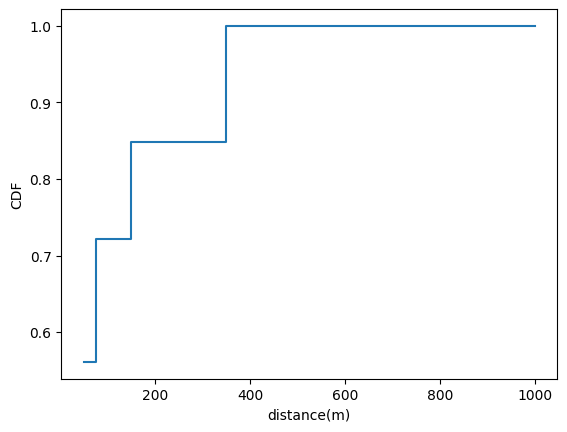

In [6]:
import numpy as np
import matplotlib.pyplot as plt

hist, edges = np.histogram(dists, bins=[0,50,100,200,500,1000])
cdf = np.cumsum(hist) / len(dists)
plt.step(edges[1:], cdf, where="mid")
plt.xlabel("distance(m)"); plt.ylabel("CDF")


In [ ]:
import overpy

api = overpy.Overpass()
# 강남구 대략 바운딩 박스(위도,경도)를 직접 지정하세요
bbox = (37.49, 127.02, 37.52, 127.06)
query = f"""
node
  [amenity=bar]
  ({bbox[0]},{bbox[1]},{bbox[2]},{bbox[3]});
out;
"""
result = api.query(query)

# DataFrame 으로 변환
bars = []
for node in result.nodes:
    bars.append({
        "lat": float(node.lat),
        "lon": float(node.lon),
        "name": node.tags.get("name","주점")
    })
df_bars = pd.DataFrame(bars)


In [10]:
df_bars

,lat,lon,name
0,37.510771,127.058226,Oak Bar
1,37.518777,127.046456,Vault +82
2,37.503847,127.052739,Band of Brewers
3,37.516956,127.038555,Hopscotch
4,37.500568,127.024887,Wood Stock
...,...,...,...
358,37.500995,127.025119,편편집 강남역2호점
359,37.504908,127.023168,메카 1988's
360,37.506995,127.024337,꽃주막
361,37.499907,127.027764,ZooSinDang Gangnam Cocktail Bar
